# SCENE: cell identity and IFN-β response

Fit cells and genes in one Euclidean space, then ask which genes lie close to a cell population.
We use the **Kang et al. (2018)** PBMC dataset from the SCENE paper: control and IFN-β-stimulated cells from eight lupus donors.

SCENE fits raw counts without normalization, log transformation, scaling, gene selection, or PCA. This tutorial keeps every gene in the curated dataset and optionally samples cells to shorten runtime. It uses the paper's 16-dimensional ZIP model; subsampling means the results will differ from the full-dataset analysis.

From the package repository, install into your notebook environment:
```bash
python -m pip install -e ".[tutorial]"
python -m jupyter lab examples/scene_quickstart_ifnb.ipynb
```
Select that environment's Python kernel. The first run downloads the full dataset; subsequent runs use the cached file.

Data: [Kang et al.](https://doi.org/10.1038/nbt.4042), using the [pertpy curated copy](https://pertpy.readthedocs.io/en/stable/_modules/pertpy/data/_datasets.html#kang_2018). No pertpy installation is needed.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
from IPython.display import display

from scene import SCENE, nearest_genes, nearest_cells, cell_gene_distances, joint_umap, plot_joint_embedding

SEED = 42
sc.settings.verbosity = 0

## 1. Load raw counts

The input is a curated count matrix. Quality control is a separate study decision, performed before fitting SCENE. We do not filter genes or use highly-variable-gene annotations.

For a shorter example, sample up to 5 cells per donor × cell type × condition. Set `cells_per_group=None` to keep every cell. Every supplied gene is retained, even if it has no counts in the sampled cells. The selected raw counts are copied into `layers["counts"]` without normalization or transformation.


In [2]:
data_path = Path("data/kang_2018.h5ad")
data_path.parent.mkdir(exist_ok=True)
adata = sc.read(
    data_path,
    backup_url="https://exampledata.scverse.org/pertpy/kang_2018.h5ad",
)

cells_per_group = 10  # None keeps the complete curated dataset.
if cells_per_group is not None:
    rng = np.random.default_rng(SEED)
    groups = adata.obs.groupby(["replicate", "cell_type", "label"], observed=True).indices
    indices = np.sort(np.concatenate([
        rng.choice(rows, size=min(cells_per_group, len(rows)), replace=False)
        for rows in groups.values()
    ]))
    adata = adata[indices].copy()
# Remove the source dataset's precomputed projections.
adata.obsm.clear()
adata.var_names_make_unique()
counts = sparse.csr_matrix(adata.X, dtype=np.float32)
assert np.isfinite(counts.data).all() and (counts.data >= 0).all()
assert np.equal(counts.data, np.floor(counts.data)).all(), "Expected raw counts"
adata.layers["counts"] = counts.copy()

markers = ["CD3D", "MS4A1", "LYZ", "NKG7", "ISG15", "IFIT3", "MX1"]
print(f"Training on {adata.n_obs:,} cells × {adata.n_vars:,} genes")
display(pd.crosstab(adata.obs["cell_type"], adata.obs["label"]))

Training on 1,158 cells × 15,706 genes


label,ctrl,stim
cell_type,,
CD4 T cells,80,80
CD14+ Monocytes,80,80
B cells,80,80
NK cells,80,80
CD8 T cells,77,80
FCGR3A+ Monocytes,80,80
Dendritic cells,80,80
Megakaryocytes,20,21


## 2. Fit SCENE with validation

Fit a 16-dimensional ZIP model without batch covariates. The paper's IFN-β fit uses random initialization, 600 epochs, a learning rate of 0.05, and full-matrix updates. These settings are explicit below; the package also supports cell minibatches when memory is limited.

For this tutorial, validation sets 10% of positive counts to zero in a separate training matrix (`validation_mode="flipped"`). The input AnnData remains unchanged. Held-out positive counts are compared with sampled observed zeros every 10 epochs. The training loss and validation ROC AUC describe fitting and count-detection performance.


[0001/600] loss=0.8294 likelihood=ZIP AUC=0.546 PR AUC=0.537 max F1=0.667 PoissonDeviance=9.868
[0100/600] loss=0.1402 likelihood=ZIP AUC=0.918 PR AUC=0.918 max F1=0.840 PoissonDeviance=0.915
[0200/600] loss=0.1289 likelihood=ZIP AUC=0.922 PR AUC=0.923 max F1=0.843 PoissonDeviance=0.717
[0300/600] loss=0.1249 likelihood=ZIP AUC=0.921 PR AUC=0.922 max F1=0.841 PoissonDeviance=0.683
[0400/600] loss=0.1231 likelihood=ZIP AUC=0.920 PR AUC=0.922 max F1=0.841 PoissonDeviance=0.677
[0500/600] loss=0.1221 likelihood=ZIP AUC=0.920 PR AUC=0.922 max F1=0.840 PoissonDeviance=0.680
[0600/600] loss=0.1214 likelihood=ZIP AUC=0.920 PR AUC=0.922 max F1=0.840 PoissonDeviance=0.690


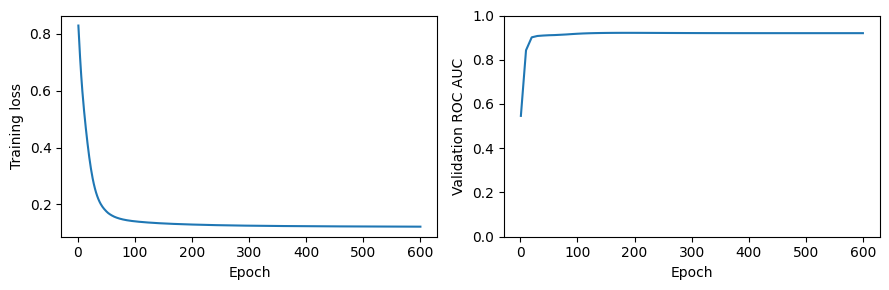

In [3]:
model = SCENE(latent_dim=16, likelihood="ZIP")
model.fit(
    adata,
    layer="counts",
    batch_keys=None,
    cell_init="random",
    gene_init="random",
    validate=True,
    val_interval=10,
    epochs=600,
    print_every=100,
    lr=0.05,
    cell_batch_size=None,
    seed=SEED,
    device="cpu",
)

training_history = model.training_history
validation = pd.DataFrame(training_history["validation"])
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(training_history["train"]["epoch"], training_history["train"]["loss"])
axes[0].set(xlabel="Epoch", ylabel="Training loss")
axes[1].plot(validation["epoch"], validation["AUC"])
axes[1].set(xlabel="Epoch", ylabel="Validation ROC AUC", ylim=(0, 1))
plt.tight_layout()
plt.show()

## 3. View the joint embedding

Fit one UMAP to the combined 16-dimensional cell and gene coordinates. All three panels use the same joint UMAP, colored by cell identity, stimulation condition, or donor; crosses mark selected genes. UMAP is a nonlinear visualization and does not preserve exact SCENE distances. All gene rankings and distances below use the original **16-dimensional SCENE coordinates**.

In [4]:
adata

AnnData object with n_obs × n_vars = 1158 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name'
    uns: 'SCENE'
    obsm: 'SCENE'
    varm: 'SCENE'
    layers: 'counts'

/Users/oscarmoberg/Documents/Industrial_PhD/Projects/SCENE/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


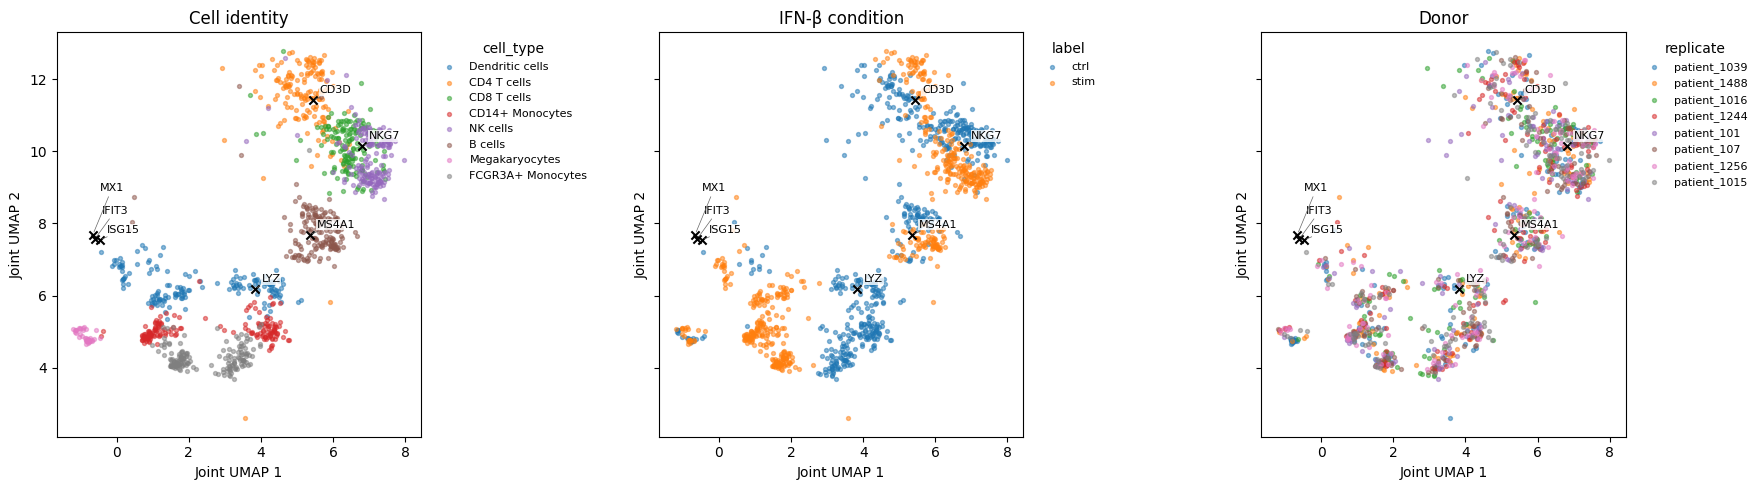

In [5]:
joint_xy = joint_umap(adata, seed=SEED)
selected = [gene for gene in markers if gene in adata.var_names]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for ax, column, title in zip(axes, ["cell_type", "label", "replicate"],
                             ["Cell identity", "IFN-β condition", "Donor"]):
    plot_joint_embedding(adata, color=column, genes=selected, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()


## 4. Ask which genes are nearby

Compare genes closest to the **CD14+ monocyte centroid** in each condition. You can also query one cell or find a gene's nearest gene neighbors. Smaller distance means closer in the fitted geometry; these rankings are not differential-expression tests or significance estimates.

In [6]:
monocytes = adata.obs["cell_type"] == "CD14+ Monocytes"
rankings = {}
for condition in ["ctrl", "stim"]:
    cells = adata.obs_names[monocytes & (adata.obs["label"] == condition)]
    rankings[condition] = nearest_genes(adata, cells=cells, n_genes=10).reset_index()
display(pd.concat(rankings, axis=1))

display(nearest_genes(adata, gene="ISG15", n_genes=10))
# Single-cell query: nearest_genes(adata, cells=adata.obs_names[0])

ctrl                     stim          
            gene  distance           gene  distance
0   RP11-366L5.1  1.390406       APOBEC3A  2.301085
1          VSIG4  1.681907          EPHB2  2.371227
2            MN1  2.142128           OTOF  2.701030
3         RNF215  2.252155           TYMP  2.719740
4         HSF2BP  2.307043           MT1M  2.733115
5          STAB1  2.401891         PIWIL4  2.896015
6           IER3  2.505919  RP11-519G16.3  2.921834
7   RP11-23P13.7  2.524196           CCL8  3.045977
8     CTB-61M7.2  2.527292         DYNLT1  3.108983
9  RP11-737O24.5  2.552208           TFEC  3.113282

,distance
gene,
IFITM3,1.967583
LY6E,2.049319
HES4,2.324951
MX2,2.353850
ISG20,2.377146
IFI6,2.394512
OAS1,2.448538
SAMD9L,2.449868
SPATS2L,2.497860


To inspect one IFN-response gene directly, measure each monocyte's distance to **ISG15** in the fitted space. This descriptive comparison pools donors; it is not a donor-aware treatment-effect test.

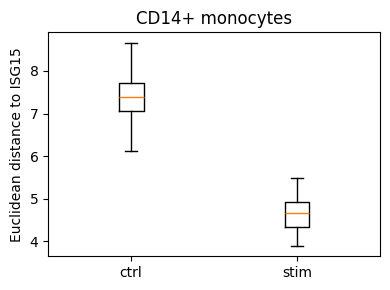

,distance
cell,
GTCCAGCTTGCCAA-2,3.760767
GTCATACTGTGCTA-2,3.794159
GTATCTACTTCTAC-2,3.796317
TGCAATCTGAGACG-2,3.888499
TATGTCTGGTTGTG-2,3.910726


In [7]:
distance_table = cell_gene_distances(adata, cells=adata.obs_names, genes="ISG15")
distance = distance_table["distance"].to_numpy()
conditions = ["ctrl", "stim"]
values = [distance[monocytes & (adata.obs["label"] == c)] for c in conditions]
fig, ax = plt.subplots(figsize=(4, 3))
ax.boxplot(values, showfliers=False)
ax.set_xticks([1, 2], conditions)
ax.set(ylabel="Euclidean distance to ISG15", title="CD14+ monocytes")
plt.tight_layout()
plt.show()

display(nearest_cells(adata, gene="ISG15", n_cells=5))


## 5. Predict, save, and reload

Named prediction pairs use the fitted batch encoding automatically. A single gene name is paired with each requested cell; predictions concern fitted cells and genes. Model expectations are distinct from geometric distances and observed counts.

Save a model directory for predictions after reload, and an H5AD for geometry, annotations, history, and fitted effects. The checkpoint does not require the original count matrix. `overwrite=True` here allows rerunning this notebook against its own checkpoint.


In [ ]:
query_cells = adata.obs_names[:3].tolist()
expected = model.expected_counts(cells=query_cells, genes="ISG15")
display(expected)

checkpoint_path = Path("scene_ifnb_model")
model.save(checkpoint_path, overwrite=checkpoint_path.exists())
restored = SCENE.load(checkpoint_path)
reloaded_expected = restored.expected_counts(cells=query_cells, genes="ISG15")
pd.testing.assert_frame_equal(expected, reloaded_expected)

output_path = Path("scene_ifnb.h5ad")
adata.write_h5ad(output_path)
reopened = sc.read_h5ad(output_path)
display(nearest_genes(reopened, gene="ISG15", n_genes=5))
display(pd.DataFrame(reopened.uns["SCENE"]["training_history"]["validation"]).tail())
